In [ ]:
# =============================================================
# Nombre del archivo: Calidad de Datos CSV.ipynb
# Autor: María José Soto Castro
# Fecha de creación: 20-10-2025
# Descripción: Descripción de calidad de los CSV de patadas y por vaca ####.csv-
# Dependencias: NUMPY, OS, PANDAS, MATPLOTLIB, SEABORN, SKLEARN, COLAB
# =============================================================

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
!ls "/content/gdrive/MyDrive/Equipo 5/"

'0. Background'
'1. Business Undersatanding'
'2. Data Understanding'
'3. Data Preparation'
'4. Modeling'
'5. Evaluation'
'6. Deployment'
'Acuerdo de trabajo de MuuMetrics.gdoc'
'Acuerdos Socioformador'
 Bacthes
 bOwOte
'Estándar de codificación y documentación.gdoc'
'Guía de Supervivencia Escolar de MuuMetrics.gdoc'
'Horarios de Trabajo y Descanso MuuMetrics.gsheet'
 MuuPVG.gsheet
'Plantilla acuerdo MuuMetrics.gdoc'
'Privacidad y seguridad de los datos .gdoc'
 Vacas


In [ ]:
path = "/content/gdrive/MyDrive/Equipo 5/2. Data Understanding/Datasets/patadas_180725.csv"
if not os.path.exists(path):
    print(f"La ruta no existe. Asegúrate de que la ruta '{path}' es correcta.")
else:
    print(f"Ruta de imágenes configurada a: {path}")

Ruta de imágenes configurada a: /content/gdrive/MyDrive/Equipo 5/2. Data Understanding/Datasets/patadas_180725.csv


In [ ]:
# The path variable already contains the full path to the file.
# No need to use os.path.join again.
patadasDF = pd.read_csv(path, delimiter=',')

In [ ]:
# Define the list of columns to keep
columnsToKeep = [
    'Número del animal',
    'DEL'
]

# Filter the DataFrame to keep only the specified columns
patadasDF = patadasDF[columnsToKeep]

# Display the first few rows to verify the changes
display(patadasDF.head())

,Número del animal,DEL
0,1554,158
1,8771,4
2,6178,264
3,2076,354
4,1624,335


In [ ]:
print(patadasDF.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Número del animal  37 non-null     int64
 1   DEL                37 non-null     int64
dtypes: int64(2)
memory usage: 724.0 bytes
None


In [ ]:
print('Min. DEL', patadasDF['DEL'].min())

print('Max. DEL', patadasDF['DEL'].max())

Min. DEL 0
Max. DEL 438


Conteo de valores en la columna 'DEL' agrupados en bins de 50:
DEL
[0, 50)       12
[50, 100)      5
[100, 150)     1
[150, 200)     3
[200, 250)     1
[250, 300)     5
[300, 350)     4
[350, 400)     4
[400, 450)     2
Name: count, dtype: int64


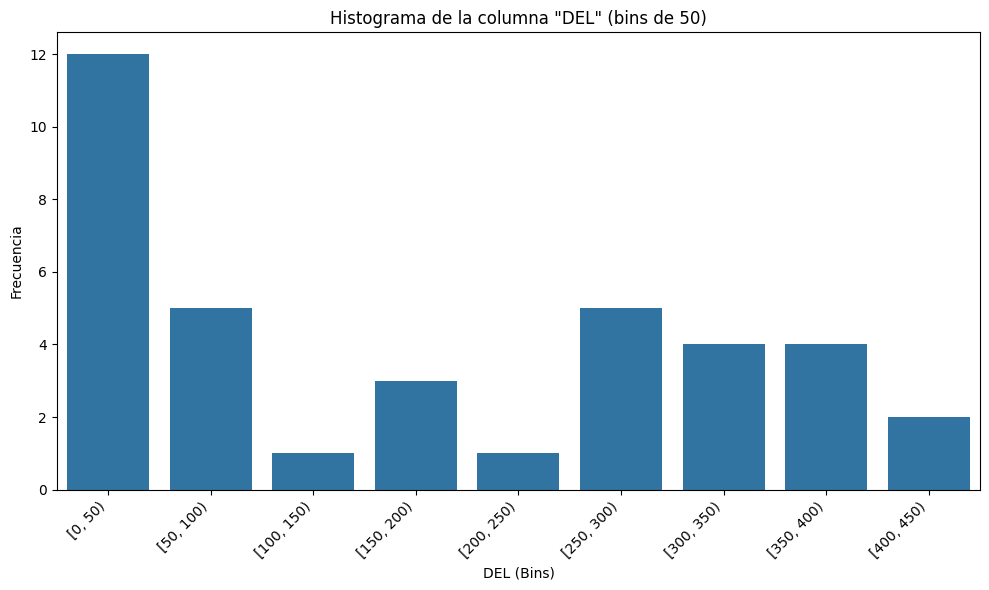

In [ ]:
# Define the column of interest
delColumn = 'DEL'

# Check if the column exists in the DataFrame and is numeric
if delColumn in patadasDF.columns and pd.api.types.is_numeric_dtype(patadasDF[delColumn]):
    # Define the bin size
    BIN_SIZE = 50

    # Create bins
    # Determine the range of the data
    minDEL = patadasDF[delColumn].min()
    maxDEL = patadasDF[delColumn].max()

    # Create bin edges, ensuring they cover the full range
    # We add BIN_SIZE to the max to ensure the last bin includes the maximum value
    bins = np.arange(0, maxDEL + BIN_SIZE, BIN_SIZE)


    # Group the data into bins and count occurrences
    # Use include_lowest=True to include the left edge of the first bin
    # Use right=False to include the right edge of each bin (except the last one)
    delBinned = pd.cut(patadasDF[delColumn], bins=bins, right=False, include_lowest=True)

    # Get the value counts for each bin
    binCounts = delBinned.value_counts().sort_index()


    print(f"Conteo de valores en la columna '{delColumn}' agrupados en bins de {BIN_SIZE}:")
    print(binCounts)

    # Generate a bar plot of the bin counts
    plt.figure(figsize=(10, 6))
    # Convert intervals to strings for better x-axis labels
    sns.barplot(x=binCounts.index.astype(str), y=binCounts.values)
    plt.title(f'Histograma de la columna "{delColumn}" (bins de {BIN_SIZE})')
    plt.xlabel(f'{delColumn} (Bins)')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
elif delColumn not in patadasDF.columns:
    print(f"La columna '{delColumn}' no se encuentra en el DataFrame.")
else:
     print(f"La columna '{delColumn}' no es numérica y no puede ser agrupada.")

In [ ]:
numericalColumns = ['DEL']
patadasDFNumerical = patadasDF[numericalColumns]

#checar nan
print("Missing values before handling:")
print(patadasDFNumerical.isnull().sum())

# Handle missing values (no missing values in this case based on previous info())
# If there were missing values, we could use:
# patadasDFNumerical = patadasDFNumerical.dropna() # To drop rows with missing values
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# patadasDFNumerical = imputer.fit_transform(patadasDFNumerical) # To impute with mean

# Scale the data
scaler = StandardScaler()
patadasScaled = scaler.fit_transform(patadasDFNumerical)

# Display the first few rows of the scaled data
print("\nScaled data (first 5 rows):")
print(patadasScaled[:5])

Missing values before handling:
DEL    0
dtype: int64

Scaled data (first 5 rows):
[[-0.12485346]
 [-1.2011243 ]
 [ 0.61595633]
 [ 1.24494578]
 [ 1.11215912]]


In [ ]:

# Choose a suitable number of clusters (e.g., 3 based on the histogram)
NUM_CLUSTERS = 3

# Instantiate a KMeans object
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)

# Fit the KMeans model to the scaled data
kmeans.fit(patadasScaled)

# Get the cluster labels
clusterLabels = kmeans.labels_

# Add the cluster labels to the original DataFrame
patadasDF['kmeans_cluster'] = clusterLabels

# Display the first few rows with the new cluster column
display(patadasDF)

,Número del animal,DEL,kmeans_cluster
0,1554,158,2
1,8771,4,0
2,6178,264,2
3,2076,354,1
4,1624,335,1
5,1233,359,1
6,6191,89,0
7,8777,42,0
8,2078,396,1
9,2080,302,1


In [ ]:
# Display info for each K-means cluster directly from patadasDF
if 'kmeans_cluster' in patadasDF.columns:
    print("Information for each K-Means cluster (Summary Statistics of 'DEL'):")
    for cluster_label in sorted(patadasDF['kmeans_cluster'].unique()):
        print(f"\n--- K-Means Cluster {cluster_label} ---")
        display(patadasDF[patadasDF['kmeans_cluster'] == cluster_label]['DEL'].describe())
else:
    print("K-Means clustering results not found in patadasDF. Please run the K-means clustering cell first.")

Information for each K-Means cluster (Summary Statistics of 'DEL'):

--- K-Means Cluster 0 ---


,DEL
count,18.000000
mean,42.666667
std,35.032758
min,0.000000
25%,15.500000
50%,32.000000
75%,81.250000
max,100.000000



--- K-Means Cluster 1 ---


,DEL
count,12.000000
mean,351.416667
std,47.620581
min,292.000000
25%,317.750000
50%,344.500000
75%,378.000000
max,438.000000



--- K-Means Cluster 2 ---


,DEL
count,7.000000
mean,217.428571
std,41.744689
min,158.000000
25%,184.500000
50%,226.000000
75%,252.500000
max,264.000000


## K-Mean Cluster



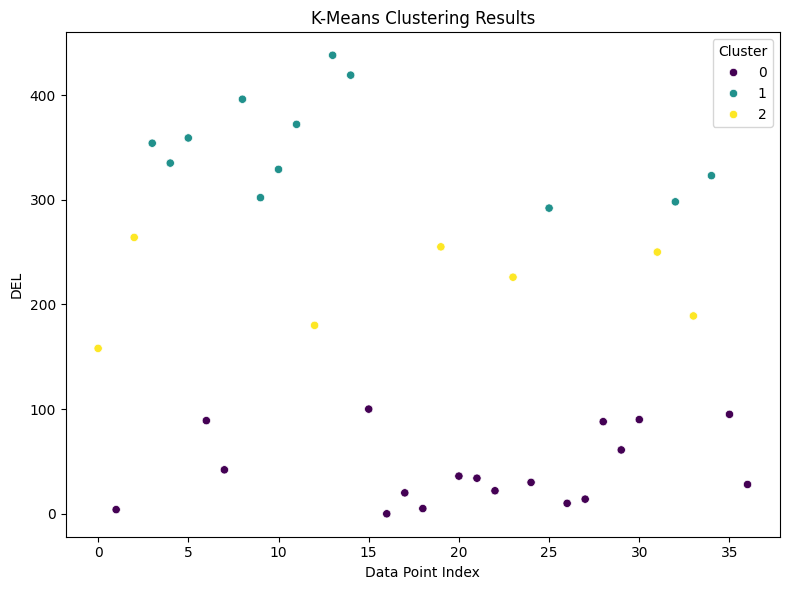

In [ ]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(figsize=(8, 6)) # Adjusted figure size for a single plot

clusteringResults = {
    'K-Means': 'kmeans_cluster',
}

# Iterate through each clustering algorithm and create a scatter plot
for title, colName in clusteringResults.items():
    if colName in patadasDF.columns:
        sns.scatterplot(data=patadasDF, x=patadasDF.index, y='DEL', hue=colName, ax=axes, palette='viridis', legend='full')
        axes.set_title(f'{title} Clustering Results')
        axes.set_xlabel('Data Point Index')
        axes.set_ylabel('DEL')
        axes.legend(title='Cluster')
    else:
        print(f"Clustering results for '{title}' ({colName}) not found in the DataFrame.")


# Adjust layout and display the plots
plt.tight_layout()
plt.show()

# ####.csv

In [ ]:

path = "/content/gdrive/MyDrive/Equipo 5/2. Data Understanding/Datasets/"
if not os.path.exists(path):
    print(f"La ruta no existe. Asegúrate de que la ruta '{path}' es correcta.")
else:
    print(f"Ruta de imágenes configurada a: {path}")

Ruta de imágenes configurada a: /content/gdrive/MyDrive/Equipo 5/2. Data Understanding/Datasets/


In [ ]:
FILE_PATH = os.path.join(path, 'combined_four_digit_files.csv')
try:
    combinedDF = pd.read_csv(FILE_PATH, skiprows=1, encoding='utf-8')
    print("Read with utf-8 encoding.")
except UnicodeDecodeError:
    try:
        combinedDF = pd.read_csv(FILE_PATH, skiprows=1, encoding='latin1')
        print("Read with latin1 encoding.")
    except Exception as e:
        print(f"Could not read the file with utf-8 or latin1 encoding. Error: {e}")
        combinedDF = pd.DataFrame() # Create an empty DataFrame if reading fails

Read with utf-8 encoding.


## Definir campos importantes


In [ ]:
# Define the list of columns to keep
columnsToKeep = [
    'Hora de inicio'
]

# Filter the DataFrame to keep only the specified columns
combinedDF = combinedDF[columnsToKeep]

# Display the first few rows to verify the changes
display(combinedDF.head())

,Hora de inicio
0,01/03/2025 06:36 a. m.
1,01/03/2025 10:01 p. m.
2,02/03/2025 05:51 a. m.
3,03/03/2025 01:35 a. m.
4,03/03/2025 07:29 a. m.


### Sacar tipo de datos y cantidad de datos

In [ ]:
print(combinedDF.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7282 entries, 0 to 7281
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Hora de inicio  7282 non-null   object
dtypes: object(1)
memory usage: 57.0+ KB
None


## Checar para datos nulos

In [ ]:
# Check for null values in each column
nullCounts = combinedDF.isnull().sum()

# Display the null counts
print("Cantidad de datos nulos por columna:")
print(nullCounts)

Cantidad de datos nulos por columna:
Hora de inicio    0
dtype: int64


DataFrame with extracted 'Hora' column:


,Hora de inicio,Hora
0,01/03/2025 06:36 a. m.,6
1,01/03/2025 10:01 p. m.,22
2,02/03/2025 05:51 a. m.,5
3,03/03/2025 01:35 a. m.,1
4,03/03/2025 07:29 a. m.,7



33 rows were dropped because the hour could not be extracted.


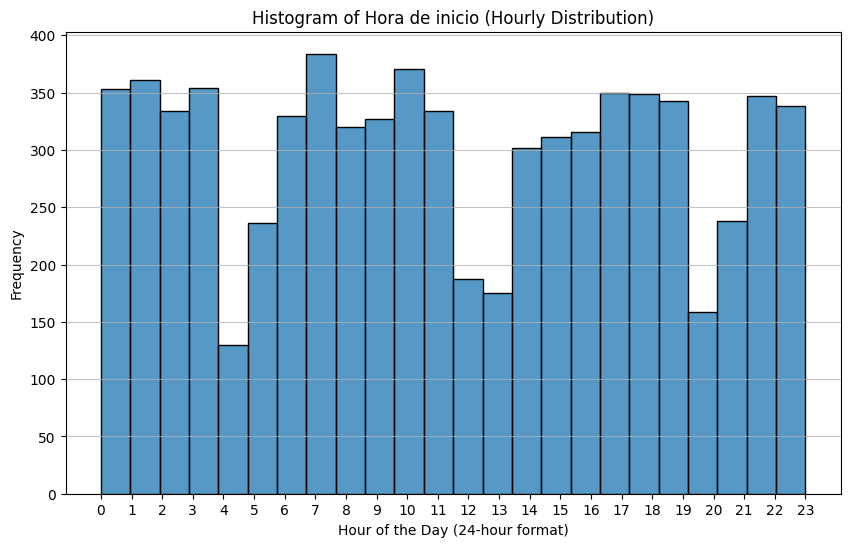

In [ ]:
import re

# Function to extract hour and convert to 24-hour format using regex
def extract_hour(time_str):
    if isinstance(time_str, str):
        # Regex to capture hour, minute, and AM/PM
        match = re.match(r'\d{2}/\d{2}/\d{4}\s+(\d{1,2}):\d{2}\s+([ap])\. m\.', time_str)
        if match:
            hour = int(match.group(1))
            timeAmPm = match.group(2).lower()

            if timeAmPm == 'p' and hour != 12:
                hour += 12
            elif timeAmPm == 'a' and hour == 12:
                hour = 0 # 12 AM is 0 in 24-hour format
            return hour
    return None # Return None for values that don't match the pattern

# Apply the extraction function to the 'Hora de inicio' column
combinedDF['Hora'] = combinedDF['Hora de inicio'].apply(extract_hour)

# Drop rows where hour extraction failed (resulted in None)
combinedDF.dropna(subset=['Hora'], inplace=True)

# Convert 'Hora' column to integer type
combinedDF['Hora'] = combinedDF['Hora'].astype(int)


# Display the first few rows with the new 'Hora' column
print("DataFrame with extracted 'Hora' column:")
display(combinedDF.head())

# Check how many rows remained after dropping failed extractions
initialRows = 7282 # Based on the output of combinedDF.info() before dropping
rowsAfterDropna = len(combinedDF)
print(f"\n{initialRows - rowsAfterDropna} rows were dropped because the hour could not be extracted.")


# Create a histogram of the 'Hora' column
if not combinedDF.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combinedDF, x='Hora', bins=24, kde=False)
    plt.title('Histogram of Hora de inicio (Hourly Distribution)')
    plt.xlabel('Hour of the Day (24-hour format)')
    plt.ylabel('Frequency')
    plt.xticks(range(24)) # Set x-axis ticks to represent each hour
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("\nNo data remaining after extracting hour. Cannot generate histogram.")

DataFrame with extracted 'Day' column:


,Hora de inicio,Hora,Day
0,01/03/2025 06:36 a. m.,6,1
1,01/03/2025 10:01 p. m.,22,1
2,02/03/2025 05:51 a. m.,5,2
3,03/03/2025 01:35 a. m.,1,3
4,03/03/2025 07:29 a. m.,7,3


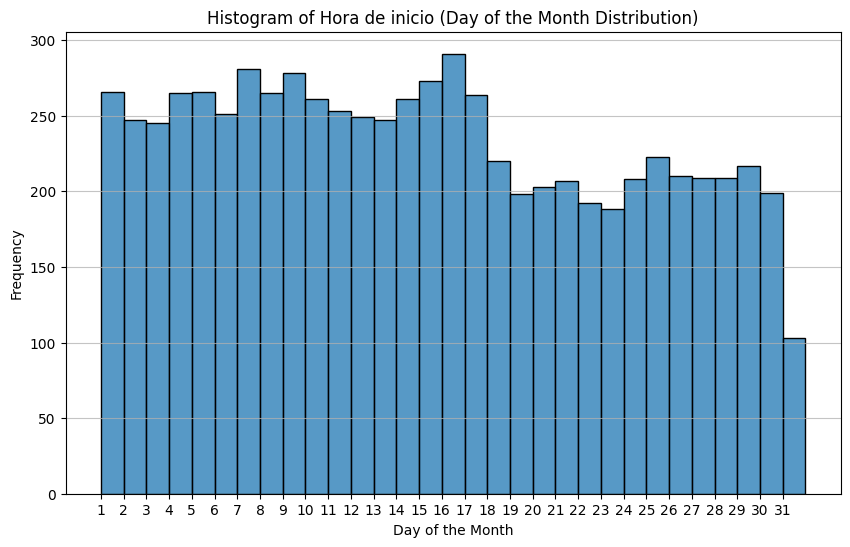

In [ ]:
import re

# Function to extract the day from the 'Hora de inicio' string
def extract_day(time_str):
    if isinstance(time_str, str):
        # Regex to capture the day
        match = re.match(r'(\d{2})/\d{2}/\d{4}\s+\d{1,2}:\d{2}\s+[ap]\. m\.', time_str)
        if match:
            return int(match.group(1))
    return None # Return None for values that don't match the pattern

# Apply the extraction function to the 'Hora de inicio' column
combinedDF['Day'] = combinedDF['Hora de inicio'].apply(extract_day)

# Drop rows where day extraction failed (resulted in None)
combinedDF.dropna(subset=['Day'], inplace=True)

# Convert 'Day' column to integer type
combinedDF['Day'] = combinedDF['Day'].astype(int)

# Display the first few rows with the new 'Day' column
print("DataFrame with extracted 'Day' column:")
display(combinedDF.head())

# Create a histogram of the 'Day' column
if not combinedDF.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=combinedDF, x='Day', bins=range(1, 33), kde=False) # Bins for days 1-31
    plt.title('Histogram of Hora de inicio (Day of the Month Distribution)')
    plt.xlabel('Day of the Month')
    plt.ylabel('Frequency')
    plt.xticks(range(1, 32)) # Set x-axis ticks for each day
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("\nNo data remaining after extracting day. Cannot generate histogram.")